<a href="https://colab.research.google.com/github/Zackkee/TAM400-Projekt/blob/main/TAM400_Projekt_Zakaria_Leon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

filsökväg = 'https://raw.githubusercontent.com/Zackkee/TAM400-Projekt/refs/heads/main/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(filsökväg)

In [2]:
display(df.head())
df.info()
print(df['Diabetes_binary'].value_counts())

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

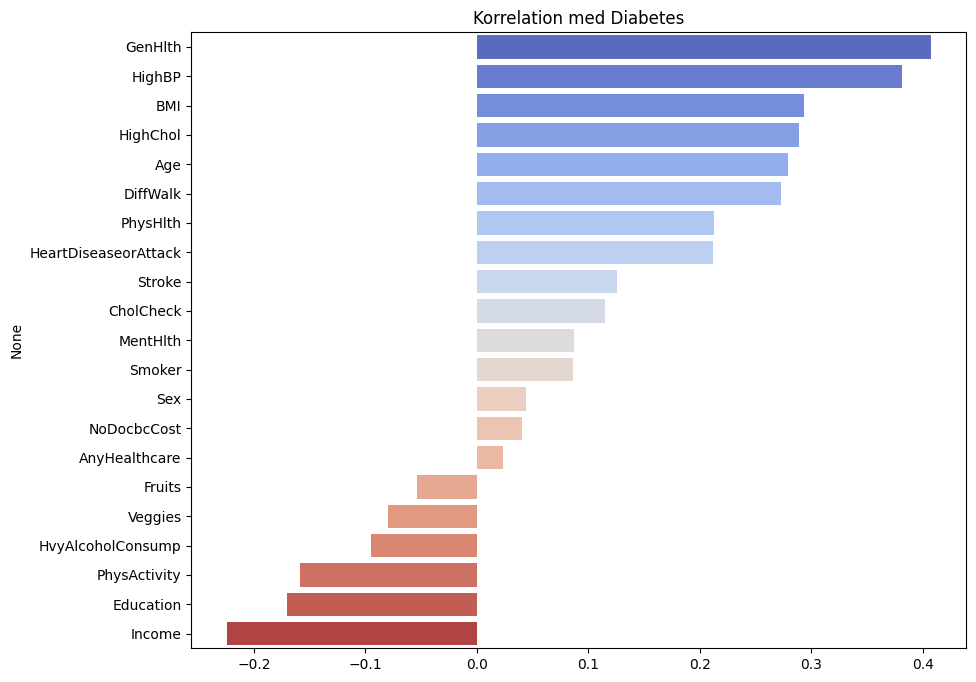

In [3]:
#Stapeldiagram
plt.figure(figsize=(10, 8))
korrelation = df.corr()['Diabetes_binary'].sort_values(ascending=False).drop('Diabetes_binary')
sns.barplot(x=korrelation.values, y=korrelation.index, hue=korrelation.index, palette='coolwarm', legend=False)
plt.title("Korrelation med Diabetes")
plt.show()

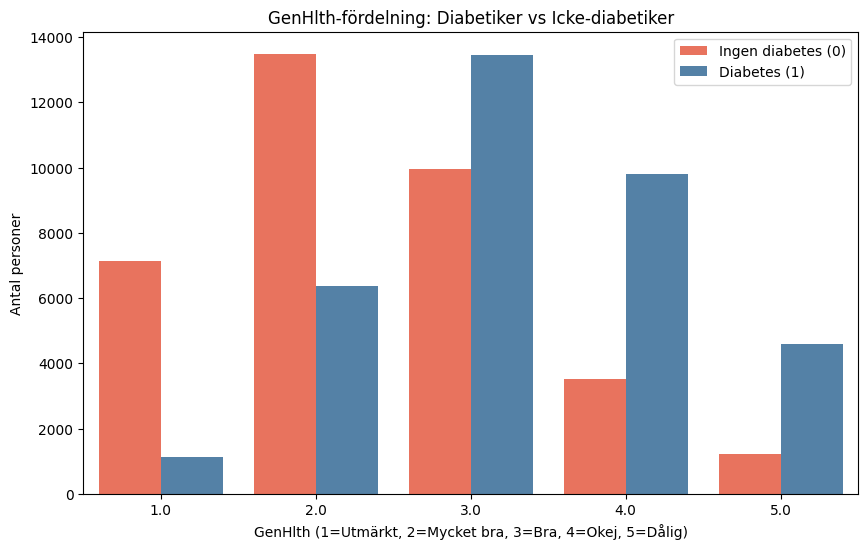

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='GenHlth', hue='Diabetes_binary',
              palette={0: 'tomato', 1: 'steelblue'})
plt.title('GenHlth-fördelning: Diabetiker vs Icke-diabetiker')
plt.xlabel('GenHlth (1=Utmärkt, 2=Mycket bra, 3=Bra, 4=Okej, 5=Dålig)')
plt.ylabel('Antal personer')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'])
plt.show()

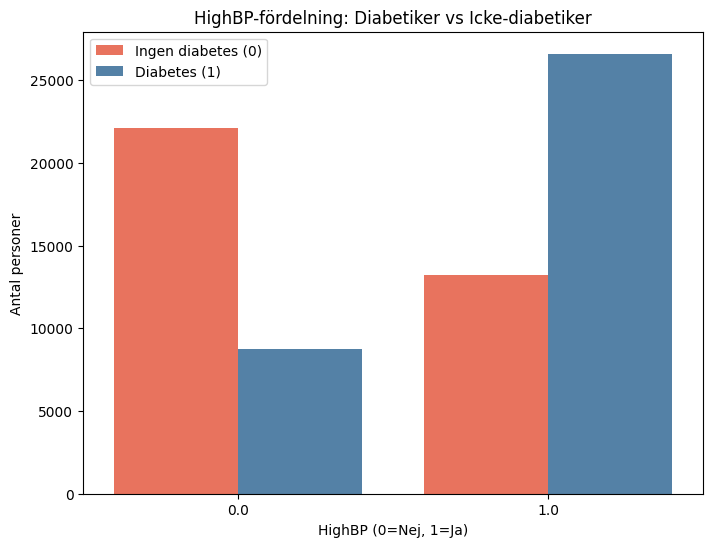

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='HighBP', hue='Diabetes_binary',
              palette={0: 'tomato', 1: 'steelblue'})
plt.title('HighBP-fördelning: Diabetiker vs Icke-diabetiker')
plt.xlabel('HighBP (0=Nej, 1=Ja)')
plt.ylabel('Antal personer')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'])
plt.show()

/tmp/ipykernel_6632/3064284080.py:17: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'], title="Hälsostatus")
/tmp/ipykernel_6632/3064284080.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'], title="Hälsostatus")


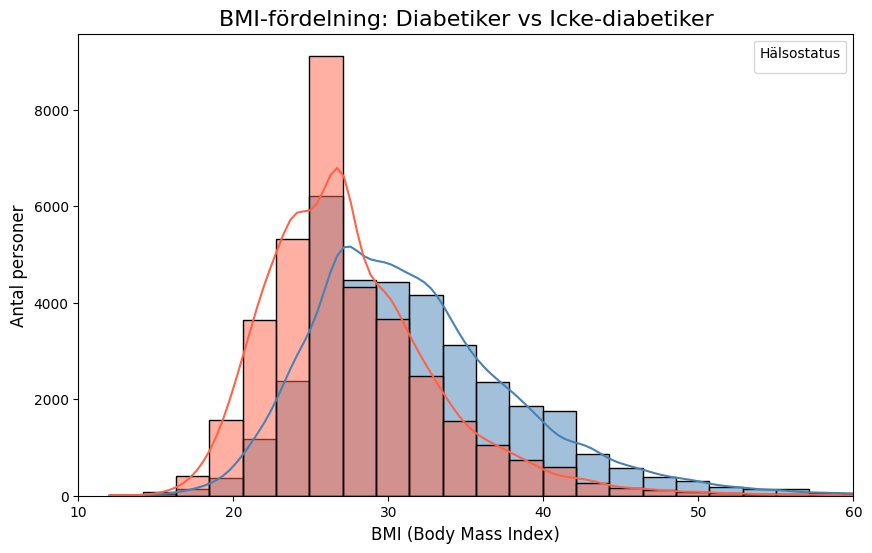

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    bins=40,
    kde=True,
    palette={0: 'tomato', 1: 'steelblue'}
)

plt.title("BMI-fördelning: Diabetiker vs Icke-diabetiker", fontsize=16)
plt.xlabel("BMI (Body Mass Index)", fontsize=12)
plt.ylabel("Antal personer", fontsize=12)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Ingen diabetes (0)', 'Diabetes (1)'], title="Hälsostatus")

plt.xlim(10, 60)
plt.show()

# Data Preprocessing(Scaling)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target variable (y)
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# 2. Train/Test split (80% training, 20% testing) WITH STRATIFY
# Genom att lägga till stratify=y garanterar vi en perfekt 50/50-balans i båda högarna
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # <-- Här är det viktiga tillägget!
)

# 3. Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is split (with stratification!) and scaled.")

Data is split (with stratification!) and scaled.


# Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Skapa och träna modellen
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Gör förutsägelser
y_pred_lr = lr_model.predict(X_test_scaled)

# Utvärdera modellen
print("Logistic Regression Resultat:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Resultat:
Accuracy: 0.7458094631869298

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139


Confusion Matrix:
[[5145 1925]
 [1669 5400]]


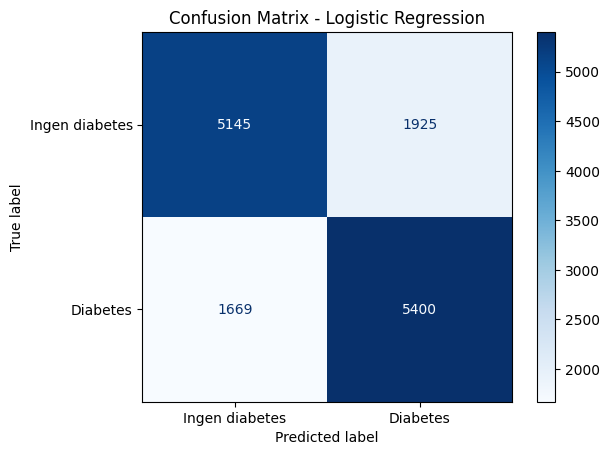

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix graf
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ingen diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Decision Trees  

Decision Tree Resultat:
Accuracy: 0.6516019520475281

Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.66      0.66      7070
         1.0       0.66      0.64      0.65      7069

    accuracy                           0.65     14139
   macro avg       0.65      0.65      0.65     14139
weighted avg       0.65      0.65      0.65     14139



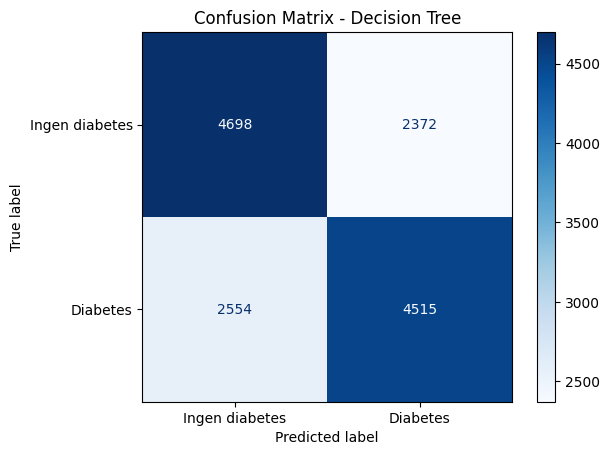

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Skapa och träna modellen
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Gör förutsägelser
y_pred_dt = dt_model.predict(X_test_scaled)

# Skriv ut resultat
print("Decision Tree Resultat:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix graf
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Ingen diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()